In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from ast import literal_eval


In [2]:
users = pd.read_csv("/content/users.tsv", sep="\t")
history = pd.read_csv("/content/history.tsv", sep="\t")
validate = pd.read_csv("/content/validate.tsv", sep="\t")
answers = pd.read_csv("/content/validate_answers.tsv", sep="\t")


In [3]:
users.head()


,user_id,sex,age,city_id
0,0,2,19,0
1,1,1,0,1
2,2,2,24,2
3,3,1,20,3
4,4,2,29,4


In [4]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27769 entries, 0 to 27768
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  27769 non-null  int64
 1   sex      27769 non-null  int64
 2   age      27769 non-null  int64
 3   city_id  27769 non-null  int64
dtypes: int64(4)
memory usage: 867.9 KB


In [5]:
users.describe(include="all")

,user_id,sex,age,city_id
count,27769.000000,27769.000000,27769.000000,27769.000000
mean,13884.000000,1.475134,28.894847,240.141165
std,8016.364149,0.501549,18.510084,466.122195
min,0.000000,0.000000,0.000000,0.000000
25%,6942.000000,1.000000,18.000000,0.000000
50%,13884.000000,1.000000,27.000000,25.000000
75%,20826.000000,2.000000,36.000000,231.000000
max,27768.000000,2.000000,118.000000,2456.000000


User - все признаки представлены целочисленными значениями, nan нет.

категориальные признаки - user id, sex(два значения - one_hot подойдет/эмбедиинг небольшой размерности),

age вообще числовой, но здесь nan заменяется 0, поэтому будет некорректно использовать его как чисто числовой признак,

city_id - числовой порядок значений не имеет семантического смысла, поэтому данный признак также требует представления в виде эмбеддингов.


In [6]:
history.head()

,hour,cpm,publisher,user_id
0,10,30.00,1,15661
1,8,41.26,1,8444
2,7,360.00,1,15821
3,18,370.00,1,21530
4,8,195.00,2,22148


In [7]:
history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1147857 entries, 0 to 1147856
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   hour       1147857 non-null  int64  
 1   cpm        1147857 non-null  float64
 2   publisher  1147857 non-null  int64  
 3   user_id    1147857 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 35.0 MB


In [8]:
history.describe()

,hour,cpm,publisher,user_id
count,1.147857e+06,1.147857e+06,1.147857e+06,1.147857e+06
mean,7.603016e+02,1.864043e+02,2.004760e+00,1.384739e+04
std,4.306159e+02,4.557257e+02,2.061949e+00,8.028620e+03
min,3.000000e+00,3.000000e+01,1.000000e+00,0.000000e+00
25%,3.920000e+02,5.500000e+01,1.000000e+00,6.817000e+03
50%,7.620000e+02,1.100000e+02,1.000000e+00,1.394100e+04
75%,1.138000e+03,2.100000e+02,2.000000e+00,2.075900e+04
max,1.490000e+03,2.090540e+05,2.100000e+01,2.776800e+04


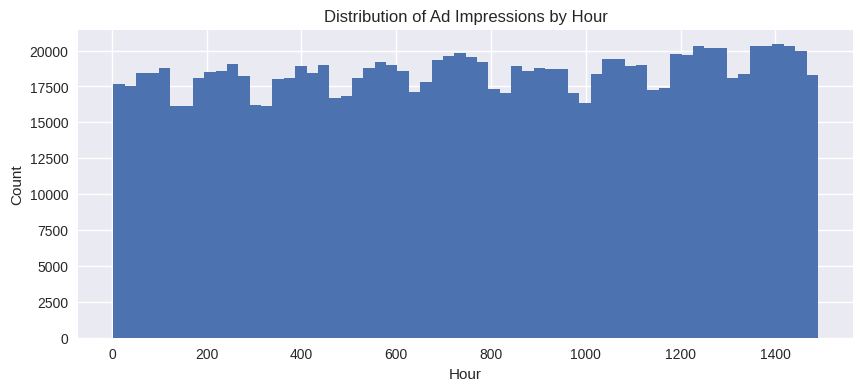

In [16]:
plt.figure(figsize=(10,4))
history["hour"].hist(bins=62)
plt.title("Distribution of Ad Impressions by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()


в таблице признак "часы" имели накопительный эффект, поэтому на графике выше я показала ситуацию по дням, разделив на 62 бина. 62*24~1490


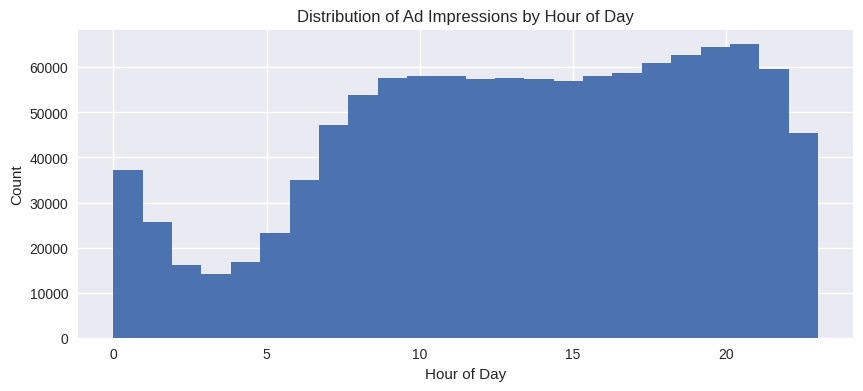

In [17]:
history["hour_of_day"] = history["hour"] % 24

plt.figure(figsize=(10,4))
history["hour_of_day"].hist(bins=24)
plt.title("Distribution of Ad Impressions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()


здесь график показывает ситуацию в течение дня.


history.tsv - история показов рекламных объявлений пользователям за два последовательных месяца.

Признаки: hour - временную компоненту показа, нельзя интерпретировать как независимую категориальную или числовую величину без учёта порядка и относительного положения во времени,

cpm - стоимость показа рекламного объявления в аукционе, высокая дисперсия, надо будет логарифмировать или нормализовывать.

publisher - категориальный идентификатор рекламной площадки. Нет порядкового смысла, поэтому рассматривается как категориальный и предполагает embedding.

In [10]:
validate.head()

,cpm,hour_start,hour_end,publishers,audience_size,user_ids
0,220.0,1058,1153,"7,17",1906,"12,44,46,50,58,71,93,122,134,143,176,184,187,1..."
1,312.0,1295,1301,"3,18",1380,"29,81,98,102,165,167,195,205,218,231,242,263,3..."
2,70.0,1229,1249,"1,2,3,9,15,21",888,"12,23,25,29,45,85,92,124,156,190,272,334,456,5..."
3,240.0,1295,1377,"1,14",440,"44,122,187,209,242,255,312,345,382,465,513,524..."
4,262.0,752,990,"1,3,7,8",1476,"15,24,30,43,50,53,96,105,159,168,181,190,196,2..."


In [11]:
validate[["publishers", "user_ids"]].iloc[0]

,0
publishers,"7,17"
user_ids,"12,44,46,50,58,71,93,122,134,143,176,184,187,1..."


In [12]:
validate["publishers"] = validate["publishers"].apply(literal_eval)
validate["user_ids"] = validate["user_ids"].apply(literal_eval)

In [13]:
validate["audience_size"].describe()

,audience_size
count,1008.000000
mean,1090.087302
std,613.557243
min,300.000000
25%,575.000000
50%,960.000000
75%,1464.000000
max,2500.000000


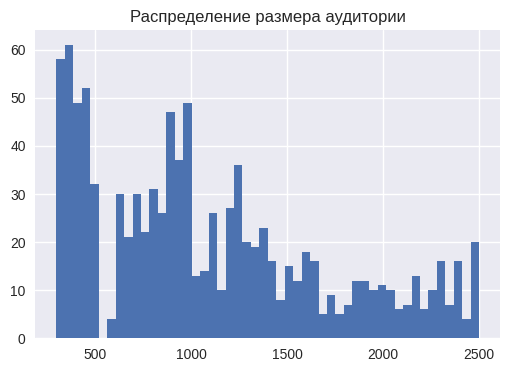

In [18]:
plt.figure(figsize=(6,4))
validate["audience_size"].hist(bins=50)
plt.title("Распределение размера аудитории")
plt.show()

In [19]:
answers.describe()

,at_least_one,at_least_two,at_least_three
count,1008.000000,1008.000000,1008.000000
mean,0.115441,0.065805,0.047170
std,0.146146,0.117812,0.099029
min,0.000000,0.000000,0.000000
25%,0.016650,0.000000,0.000000
50%,0.055250,0.009800,0.001400
75%,0.158700,0.078125,0.048950
max,0.930700,0.909700,0.883400


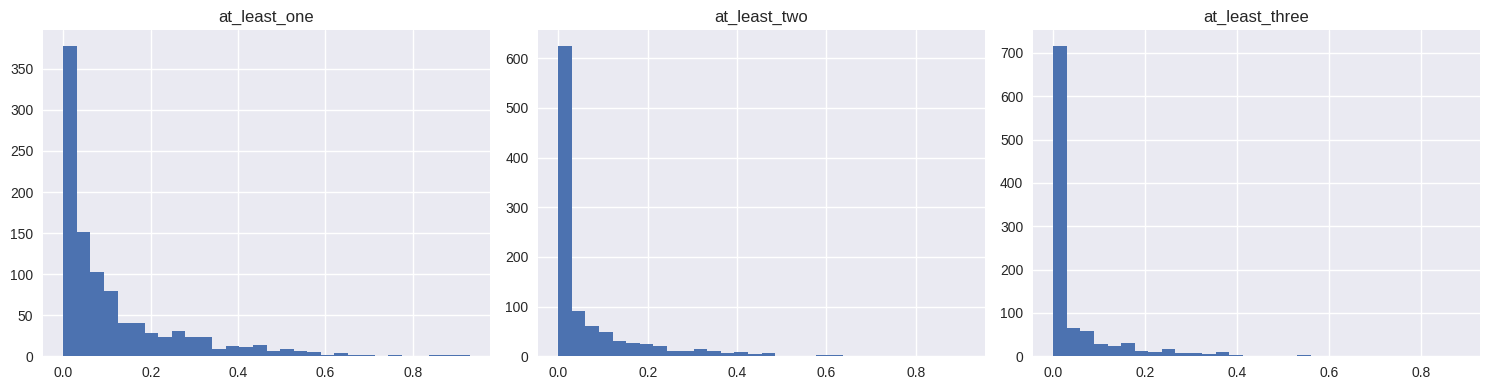

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, col in zip(axes, answers.columns):
    answers[col].hist(bins=30, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


Здесь мы видим плавное убывание: большинство кампаний имеют относительно малую долю пользователей, которые увидят рекламу многократно, и лишь небольшая часть кампаний достигает высокой доли.

Это отражает естественную особенность аукциона: чем больше количество повторных показов, тем меньше пользователей охватывается.

In [21]:
violations = (
    (answers["at_least_three"] > answers["at_least_two"]) |
    (answers["at_least_two"] > answers["at_least_one"])
)

violations.sum()


np.int64(0)

здесь просто проверили логику. Если пользователь увидел объявление 3 раза, то он точно видел его и 1, и 2 раза)


In [22]:
history_users = set(history["user_id"])
validate_users = set(u for users_list in validate["user_ids"] for u in users_list)

len(validate_users - history_users), len(validate_users)


(2233, 27769)

Всего пользователей в целевом наборе (`validate`) — 27 769.

Пользователей, которых нет в истории показов (`history`) — 2 233.

Это означает, что около 8% пользователей целевого набора не имеют исторических данных. Для этих пользователей нужно будет использовать или отдельный embedding для "нового пользователя" или заполнять агрегаты по истории средними значениями.
